# Sudoku Image Parsing

## Image Preprocessing

Using OpenCV to extract the sudoku grid and further extract each cell separately form a given image. The cells can then be passed to PaddleOCR for recognition.

In [2]:
import cv2

IM_PATH = "data/sudoku_puzzles_book_33.jpg"

In [105]:
img = cv2.imread(IM_PATH)

def threshold(im):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    return cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV, 11, 2
    )

thresh = threshold(img)

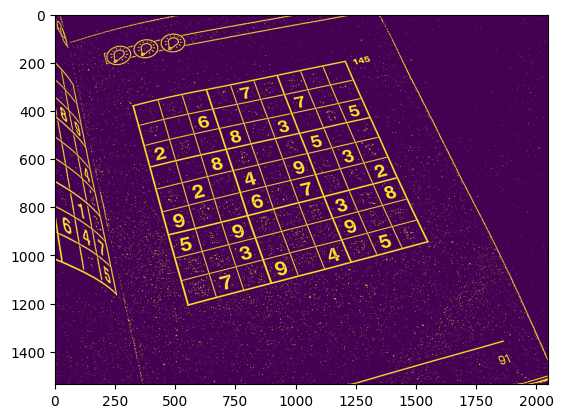

In [4]:
import matplotlib.pyplot as plt

plt.imshow(thresh)

In [ ]:
import numpy as np

def reorder(points):
    """
    Takes four points from a contour of a square
    and returns them in a consistent order:
      - top-left
      - top-right,
      - bottom-right,
      - bottom-left.
    """
    points = points.reshape((4, 2))
    new_points = np.zeros((4, 2), dtype=np.float32)

    add = points.sum(1)
    new_points[0] = points[np.argmin(add)]  # top-left
    new_points[2] = points[np.argmax(add)]  # bottom-right

    diff = np.diff(points, axis=1)
    new_points[1] = points[np.argmin(diff)]  # top-right
    new_points[3] = points[np.argmax(diff)]  # bottom-left

    return new_points

def extract_grid(img_thresh, side=450):
    # Finding contours for the image
    contours, _ = cv2.findContours(
        img_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    contour = max(contours, key=cv2.contourArea)

    peri = cv2.arcLength(contour, True)  # frame for the sukoku

    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    points = reorder(approx)

    pts1 = np.float32(points)
    pts2 = np.float32([[0, 0], [side, 0], [side, side], [0, side]])

    matrix = cv2.getPerspectiveTransform(pts1, pts2)
    warped = cv2.warpPerspective(img, matrix, (side, side))

    return warped

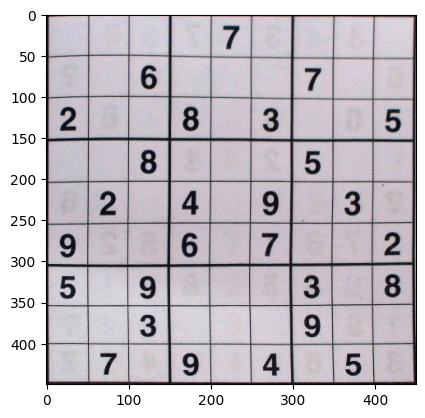

In [6]:
grid = extract_grid(thresh)

plt.imshow(grid)

In [ ]:
def read_grid(grid):
    """
    Extracts each cell from the grid.
    """
    digits = []

    cell_h = grid.shape[0] // 9
    cell_w = grid.shape[1] // 9

    for i in range(9):
        for j in range(9):
            y1, y2 = i * cell_h, (i + 1) * cell_h
            x1, x2 = j * cell_w, (j + 1) * cell_w
            cell = grid[y1:y2, x1:x2]
            digits.append(cell)

    return digits

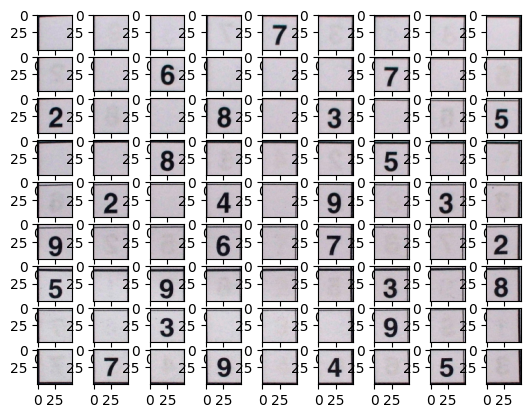

In [8]:
for i, cell in enumerate(read_grid(grid)):
    plt.subplot(9, 9, i+1)
    plt.imshow(cell)

## Optical Character Recognition

Here I need a fast and precise model. Its task is simple (recognize single digits), but it needs to be able to do this task very well.

I chose PaddleOCR for its high accuracy.

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


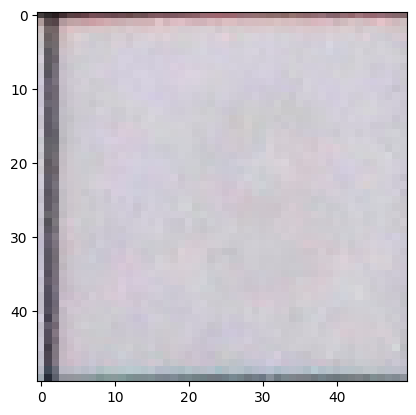

In [9]:
from paddleocr import PaddleOCR

digits = read_grid(grid)

plt.imshow(digits[1])

In [10]:
ocr = PaddleOCR(lang='en')
results = ocr.predict(digits[1])

results

/home/cian/sudoku-cracker/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/home/cian/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/home/cian/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/home/cian/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


...

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/home/cian/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('en_PP-OCRv5_mobile_rec', None)
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/home/cian/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[ 67, ...,  61],
           ...,
           [128, ..., 106]],
   
          ...,
   
          [[158, ..., 177],
           ...,
           [141, ..., 155]]], shape=(50, 50, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 90,
   'rot_img': array([[[ 0, ...,  0],
           ...,
           [ 0, ...,  0]],
   
          ...,
   
          [[46, ..., 42],
           ...,
           [38, ..., 55]]], shape=(50, 50, 3), dtype=uint8),
   'output_img': array([[[205, ..., 191],
           ...,
           [185, ..., 198]],
   
          ...,
   
          [[198, ..., 177],
           ...,
           [183, ..., 194]]], shape=(50, 50, 3), dtype=uint8)},
  'dt_polys': [],
  'model_settings': {'use_doc_preprocessor': True,
   'use_textline_orientation': True},
  'text_det_params': {'limit_si

In [11]:
results[0]["rec_texts"]

[]

In [12]:
probs = []
for i, im in enumerate(digits):
    res = ocr.predict(im)
    pred = res[0]["rec_texts"]
    probs.append(res[0]["rec_scores"])
    if len(pred) > 0 and pred[0].isdigit():
        print(pred[0], end=" ")
    else:
        print(0, end=" ")
    if (i + 1) % 9 == 0:
        print("")

0 0 0 0 7 0 0 0 0 
0 0 6 0 0 0 7 0 0 
2 0 0 8 0 3 0 0 5 
0 0 8 0 0 0 5 0 0 
0 2 0 4 0 6 0 3 0 
6 0 0 6 0 7 0 0 2 
5 0 6 0 0 0 3 0 8 
0 0 3 0 0 0 6 0 0 
0 7 0 6 0 4 0 5 0 


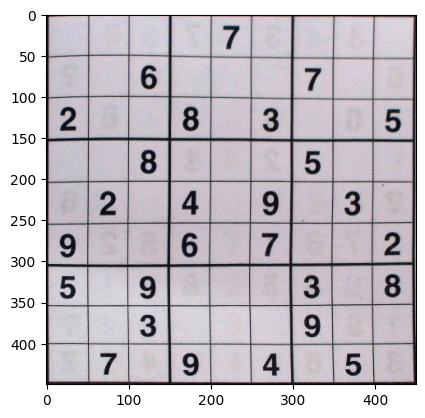

In [13]:
plt.imshow(grid)

In [ ]:
ocr.predict(grid)[0]["rec_texts"]

['7',
 '6',
 '7',
 '2',
 '8',
 '3',
 '5',
 '8',
 '5',
 '2',
 '4',
 '9',
 '3',
 '9',
 '6',
 '7',
 '2',
 '5',
 '9',
 '3',
 '8',
 '3',
 '9',
 '7',
 '9',
 '4',
 '5']

### Single digit approach fails

I tried to maintain the grid's structure by predicting one cell at a time. This was a bad idea for several reasons.

- It's terribly inefficient
- Using PaddleOCR to predict single digits borders to misusage

The model is actually amazingly accurate, but not trained for single digit recogintion. You can't blame it for mispredicting some 9's as 6's. The model probably learned to distinguish between a `9` and a `6` depending on its surroundings. It's still amazing how well it did on single digit recognition.

Looking at the result it produces on the whole image, it gets everthing correct.

Now I just need a way to tell where in the grid the populated cells are.

## Using standard deviation to distinguish empty from populated cells

A straightforward and efficient way to assess whether a cell is empty is to compute its standard deviation. A blank cell will have low standard deviation.

In [ ]:
digits = read_grid(grid)
preds = ocr.predict(grid)[0]["rec_texts"]

def gray_scale(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

def crop(im, n_px):
    return im[n_px:-n_px, n_px:-n_px]   # exclude grid lines

cropped = np.array([gray_scale(crop(i, 10)) for i in digits])

std_mask = np.std(cropped, axis=(1, 2)) > 10
std_mask = std_mask.reshape(9, 9)

assert np.sum(std_mask) == len(preds)

sudoku = np.zeros((9, 9), dtype=np.int64)
sudoku[std_mask] = preds
sudoku

array([[0, ..., 0],
       ...,
       [0, ..., 0]], shape=(9, 9))

In [104]:
np.set_printoptions(threshold=5000)

sudoku

array([[0, 0, 0, 0, 7, 0, 0, 0, 0],
       [0, 0, 6, 0, 0, 0, 7, 0, 0],
       [2, 0, 0, 8, 0, 3, 0, 0, 5],
       [0, 0, 8, 0, 0, 0, 5, 0, 0],
       [0, 2, 0, 4, 0, 9, 0, 3, 0],
       [9, 0, 0, 6, 0, 7, 0, 0, 2],
       [5, 0, 9, 0, 0, 0, 3, 0, 8],
       [0, 0, 3, 0, 0, 0, 9, 0, 0],
       [0, 7, 0, 9, 0, 4, 0, 5, 0]])

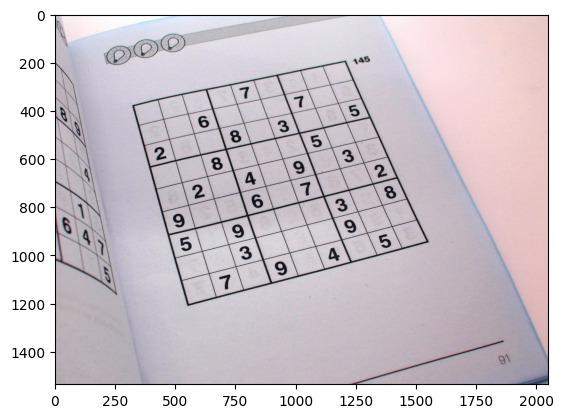

In [106]:
plt.imshow(img)

Splitting this problem into two steps:
1. Recognizing the digits
2. Recognizing the grid's structure

would provide the accuracy and efficiency needed, to implement the OCR feature into the app.